# Synthesis and Capture

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

from acadia.system import Acadia, StreamConfiguration
from acadia.channel import Channel
from acadia.arrays import ProceduralWaveform, Waveform
from acadia.data import DataManager, ArrayRecordGroup

import logging
logging.basicConfig(format='[%(asctime)s] %(threadName)s: %(message)s', datefmt='%m/%d/%Y %I:%M:%S %p', level=logging.DEBUG)

[10/04/2023 09:20:05 PM] MainThread: Loaded backend module://ipykernel.pylab.backend_inline version unknown.


# System Configuration

In [2]:
acadia = Acadia()

pulse_channel = acadia.DAC(1)

def pulse_shape(out, sample_times):
    out[:] = Channel.to_samples(0.99*np.ones(len(sample_times), dtype=np.complex64))

pulse = ProceduralWaveform(pulse_channel, pulse_shape, pulse_channel)

capture_channel = acadia.ADC(1)
capture_data = Waveform(capture_channel, 5000e-9, region=acadia.PLDDR0Array)
capture_configuration = StreamConfiguration(capture_channel, acadia=acadia)

def configure():
    pulse_channel.set_nyquist_zone(2)
    pulse_channel.configure_nco(frequency=2000e6)
    pulse_channel.set_vop(20000)
    
    capture_channel.set_nyquist_zone(2)
    capture_channel.set_dsa(0)
    
SHOTS = 1000
    
# We'll collect the data traces in a record group
traces = ArrayRecordGroup((len(capture_data),), 
                          SHOTS, 
                          dtype=np.complex64, 
                          record_axes=[capture_data.axis()])
    
# Make a data manager for storing data and serving it to a plotter
mgr = DataManager("/home/root")
mgr.add_group("traces", traces)
mgr.start_server()

[10/04/2023 09:20:05 PM] DataManager@('', 6672): Started DataManager server at ('', 6672)


## The actual meat of the program

[10/04/2023 09:20:05 PM] Plotter@('localhost', 6672): Plotter thread launched to retrieve records from ('localhost', 6672)
[10/04/2023 09:20:05 PM] Plotter@('localhost', 6672): Established connection to server ('localhost', 6672)
[10/04/2023 09:20:05 PM] DataManager@('', 6672): Received connection from ('127.0.0.1', 37468)
[10/04/2023 09:20:05 PM] Plotter@('localhost', 6672): Sent filename length 13
[10/04/2023 09:20:05 PM] DataManager@('', 6672): Filename length 13
[10/04/2023 09:20:05 PM] Plotter@('localhost', 6672): Sent filename metadata.json
[10/04/2023 09:20:05 PM] DataManager@('', 6672): Requested file metadata.json
[10/04/2023 09:20:05 PM] DataManager@('', 6672): File not found
[10/04/2023 09:20:05 PM] Plotter@('localhost', 6672): Server responded with file size 0
[10/04/2023 09:20:05 PM] Plotter@('localhost', 6672): Received no metadata
[10/04/2023 09:20:06 PM] Plotter@('localhost', 6672): Established connection to server ('localhost', 6672)
[10/04/2023 09:20:06 PM] DataManage

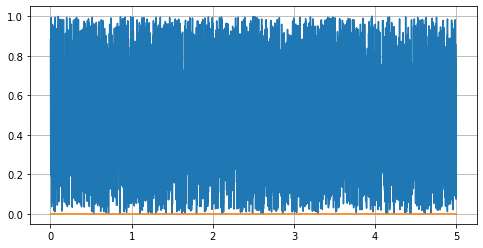

[10/04/2023 09:20:09 PM] MainThread: Saving records...
[10/04/2023 09:20:09 PM] MainThread: Saved
[10/04/2023 09:20:09 PM] MainThread: Saving records...
[10/04/2023 09:20:09 PM] MainThread: Saved
[10/04/2023 09:20:10 PM] MainThread: Saving records...
[10/04/2023 09:20:10 PM] Plotter@('localhost', 6672): Established connection to server ('localhost', 6672)
[10/04/2023 09:20:10 PM] DataManager@('', 6672): Received connection from ('127.0.0.1', 37478)
[10/04/2023 09:20:10 PM] Plotter@('localhost', 6672): Sent filename length 13
[10/04/2023 09:20:10 PM] DataManager@('', 6672): Filename length 13
[10/04/2023 09:20:10 PM] MainThread: Saved
[10/04/2023 09:20:10 PM] Plotter@('localhost', 6672): Sent filename metadata.json
[10/04/2023 09:20:10 PM] DataManager@('', 6672): Requested file metadata.json
[10/04/2023 09:20:10 PM] DataManager@('', 6672): Located file, sent size 156
[10/04/2023 09:20:10 PM] Plotter@('localhost', 6672): Server responded with file size 156
[10/04/2023 09:20:10 PM] Plotte

In [3]:
# Create a sequence for the sequencer
def sequence(a):
    with a.channel_synchronizer():
        a.generate(pulse_channel, pulse)
        a.capture(capture_configuration, capture_data)

# Because the pulse is procedurally generated, we can change its length at runtime,
# so we need to start by allocating the length to use initially
pulse.allocate(1000e-9)

# Attach to the hardware
acadia.attach()

# Load the wave memory with the pulse by calling the generator function
pulse.populate()

# Configure channel parameters using the function we defined above
configure()

# Configure the stream processing path to capture data using the configuration
# written above
acadia.configure_stream(capture_configuration)

# Compile only once
acadia.compile(sequence)

for shot in range(SHOTS):
    acadia.run()
    
    # Get the trace data and write it into a record
    trace = Channel.from_samples(capture_data.memory())
    mgr.append("traces", np.random.default_rng().random(len(trace)).astype(trace.dtype))
    
    # Wait some time until running again just so that we can see the plot update
    time.sleep(0.01)